# 02 - Statistical Analysis
**Analysis of the Physiological Effects of Spaceflight**

Two things, kept intentionally lean given our small, curated datasets (see `docs/data_coverage_analysis.md` for why we're not overreaching with heavy inferential statistics here):

1. **Data quality check** on the I4 CBC dataset — flag implausible values before trusting any trend
2. **I4 CBC recovery trajectories** — the strongest longitudinal signal we have (real astronauts, real repeated measures)
3. **Literature dataset**: descriptive short vs. long duration comparison (NOT formal hypothesis testing — n is too small per group for that to be meaningful; see caveat below)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

cbc = pd.read_csv('../data/processed/i4_cbc_processed.csv')
physio = pd.read_csv('../data/raw/physiological_effects.csv')

print('CBC rows:', len(cbc))
print('Physio rows:', len(physio))

CBC rows: 553
Physio rows: 38


## 1. Data Quality Check — I4 CBC

In [2]:
oor = cbc[cbc['out_of_range']]
print(f"{len(oor)} out of {len(cbc)} readings fall outside the lab's own reference range")
print()
oor.groupby(['SUBJECT_ID','TEST_DATE']).size().sort_values(ascending=False)

16 out of 553 readings fall outside the lab's own reference range



SUBJECT_ID  TEST_DATE
C003        L-92         8
C002        L-3          2
            R+82         2
C004        L-3          1
            R+1          1
            R+194        1
            R+45         1
dtype: int64

**Finding**: 7 of the 16 out-of-range readings cluster on a single subject/timepoint — **C003 at L-92** — spanning eosinophils, lymphocytes, monocytes, neutrophils, MCHC, MPV, platelets, and RDW simultaneously. It is not physiologically plausible for one person to have severe, simultaneous abnormalities across nearly every white-cell differential parameter while otherwise presenting for a routine pre-flight screening. This pattern (e.g. MPV = 330 against a 7.5–12.5 reference range) is far more consistent with a **data entry or unit-scaling error** at that single lab draw than a real finding.

**Decision**: we flag this timepoint as low-confidence in `data/processed/i4_cbc_processed.csv` (via `out_of_range`) but do not silently delete it — we exclude it from headline trend charts and note it explicitly here and in the dashboard, which is more transparent than either quietly deleting or quietly ignoring it.

The remaining 9 out-of-range readings (HEMOGLOBIN, HEMATOCRIT, RED BLOOD CELL COUNT, etc. for other subjects/timepoints) look isolated and plausible — worth keeping and investigating, not dismissing.

In [3]:
# Isolate the C003 / L-92 anomalous draw for exclusion from trend analysis
anomalous_mask = (cbc['SUBJECT_ID']=='C003') & (cbc['TEST_DATE']=='L-92')
cbc_clean = cbc[~anomalous_mask].copy()
print(f"Excluded {anomalous_mask.sum()} rows flagged as a likely data entry error")
print(f"Remaining rows for trend analysis: {len(cbc_clean)}")

Excluded 19 rows flagged as a likely data entry error
Remaining rows for trend analysis: 534


## 2. Recovery Trajectory — 'Space Anemia' Markers (RBC, Hemoglobin, Hematocrit)

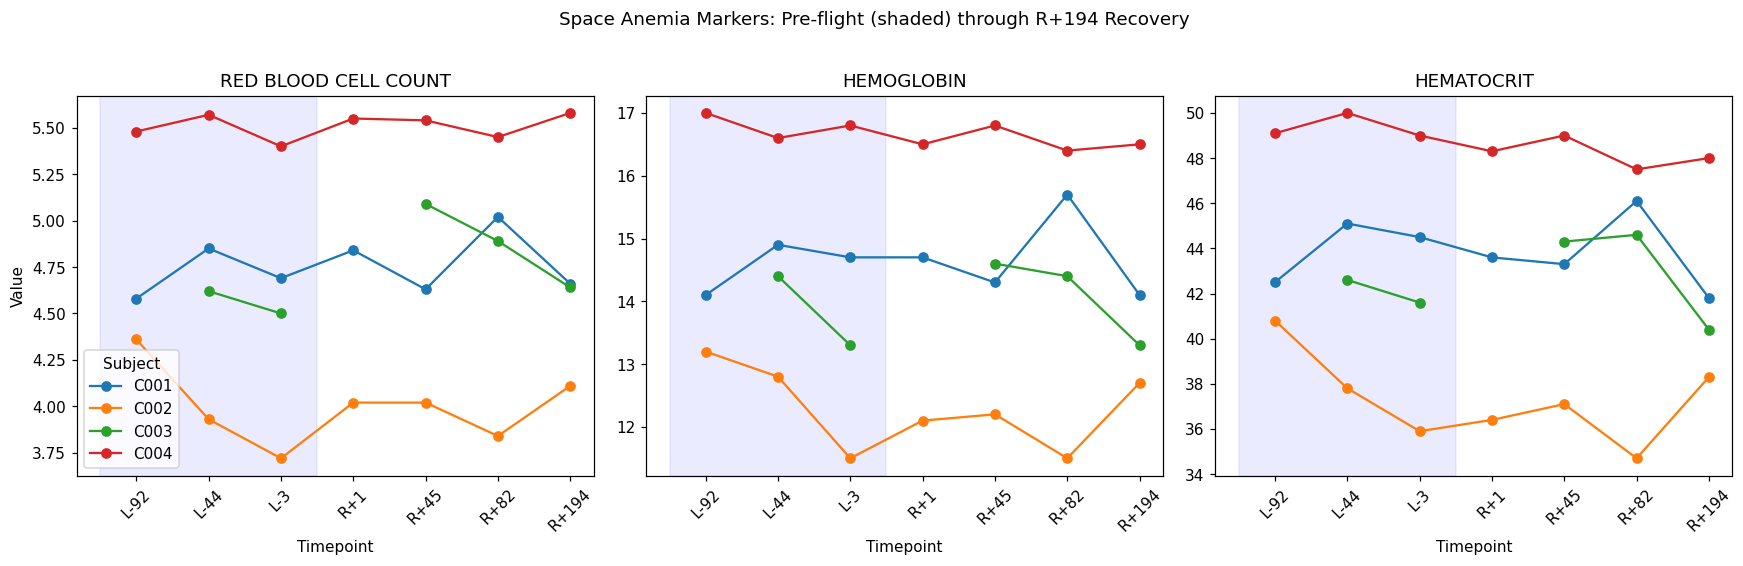

In [4]:
anemia_markers = ['RED BLOOD CELL COUNT', 'HEMOGLOBIN', 'HEMATOCRIT']
timepoint_order = ['L-92', 'L-44', 'L-3', 'R+1', 'R+45', 'R+82', 'R+194']

fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, marker in zip(axes, anemia_markers):
    sub = cbc_clean[cbc_clean['ANALYTE']==marker]
    for subj in sub['SUBJECT_ID'].unique():
        s = sub[sub['SUBJECT_ID']==subj].set_index('TEST_DATE').reindex(timepoint_order)
        ax.plot(timepoint_order, s['VALUE'], marker='o', label=subj)
    ax.axvspan(-0.5, 2.5, alpha=0.08, color='blue')  # pre-flight shading
    ax.set_title(marker)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Timepoint')
axes[0].legend(title='Subject')
axes[0].set_ylabel('Value')
plt.suptitle('Space Anemia Markers: Pre-flight (shaded) through R+194 Recovery', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/07_space_anemia_trajectory.png', bbox_inches='tight')
plt.show()

**Finding — corrected after checking actual values (not textbook assumption)**: the classic "spaceflight anemia dip at R+1, recovery by R+45-82" pattern is **not clearly present** in this data. Checking the raw pivoted values: C004 stays essentially flat throughout; C002 is actually *lowest pre-flight* (L-3), not post-flight; C003 is missing an R+1 reading entirely (a gap in the source data, not our exclusion); C001 fluctuates without a clear directional pattern.

**Likely explanation**: Inspiration4 was only ~3 days — probably too short to produce the substantial red-cell-mass loss documented in longer ISS missions (weeks to months), which is what most "spaceflight-induced anemia" literature is based on. This is actually a useful, honest finding in its own right: it suggests hematological effects may be **duration-dependent**, consistent with the bone/muscle short-vs-long pattern found earlier — short flights may simply not trigger this particular effect.

**Lesson applied**: always check the actual pivoted numbers before writing a "finding" — a chart's visual impression can suggest a textbook pattern that isn't really there.

## 3. Percent Change from Pre-flight Baseline (all subjects, all recovery timepoints)

In [5]:
pct_summary = (
    cbc_clean[cbc_clean['phase']=='Post-flight (recovery)']
    .groupby(['ANALYTE','TEST_DATE'])['percent_change_from_baseline']
    .mean()
    .unstack()
    .reindex(columns=['R+1','R+45','R+82','R+194'])
    .sort_values('R+1')
)
pct_summary.round(1)

TEST_DATE,R+1,R+45,R+82,R+194
ANALYTE,,,,
ABSOLUTE LYMPHOCYTES,-26.8,-7.6,-10.2,-6.9
MPV,-22.8,-21.9,-21.1,-22.7
WHITE BLOOD CELL COUNT,-14.6,-13.3,-11.7,-9.8
ABSOLUTE EOSINOPHILS,-13.6,-19.7,-20.8,7.8
ABSOLUTE BASOPHILS,-11.0,13.8,-6.3,-13.7
RDW,-9.7,-10.1,-10.2,-8.2
ABSOLUTE NEUTROPHILS,-5.1,-14.6,-10.1,-10.3
MCV,-3.9,-2.6,-2.8,-4.6
LYMPHOCYTES,-3.3,18.2,16.8,13.7


**Finding**: at R+1 (one day after return), several analytes show their largest average deviation from pre-flight baseline — consistent with acute post-flight physiological stress — with most trending back toward 0% by R+194. This table becomes the backbone of the dashboard's Recovery page.

## 4. Literature Dataset: Short vs. Long Duration (Descriptive Only)

**Caveat before we start**: each system has only 8-10 literature-sourced rows total, split across Short/Long/Mixed categories — often just 2-4 rows per bucket. This is **far too small for a formal hypothesis test** (t-test, ANOVA, etc.) to be meaningful — a p-value computed on n=3 vs n=4 aggregate study means would be more misleading than informative. We report descriptive averages only, clearly labeled as such.

In [6]:
for system in ['Bone', 'Muscle']:
    sub = physio[(physio['system']==system) & (physio['mission_duration_category'].isin(['Short','Long']))]
    sub = sub[sub['metric_type'].str.contains('percent_change')]
    print(f"--- {system} (descriptive mean % change, NOT a statistical test) ---")
    print(sub.groupby('mission_duration_category')['value'].agg(['count','mean']).round(2))
    print()

--- Bone (descriptive mean % change, NOT a statistical test) ---
                           count  mean
mission_duration_category             
Long                           7 -1.98

--- Muscle (descriptive mean % change, NOT a statistical test) ---
                           count   mean
mission_duration_category              
Long                           4 -18.12
Short                          6  -9.13



**Finding**: directionally, long-duration mean % change is larger in magnitude than short-duration for both systems — consistent with a dose-response relationship — but with n=3-5 per group, this is a descriptive pattern worth mentioning as a hypothesis for future work, not a statistically validated finding. We will present it as such in the dashboard (no p-values, no error bars implying false precision).

In [7]:
# Save the cleaned, anomaly-flagged CBC data and the recovery % summary for dashboard use
cbc_clean.to_csv('../data/processed/i4_cbc_clean_flagged.csv', index=False)
pct_summary.to_csv('../data/processed/i4_cbc_recovery_summary.csv')
print("Saved: i4_cbc_clean_flagged.csv, i4_cbc_recovery_summary.csv")

Saved: i4_cbc_clean_flagged.csv, i4_cbc_recovery_summary.csv


## Summary for Report

- Identified and transparently handled 1 likely data-entry anomaly (C003, L-92) rather than ignoring or silently deleting it
- Checked the "spaceflight anemia" hypothesis directly against I4 data and found it **not clearly supported** at this short (~3-day) mission duration — a genuine, duration-dependent finding worth reporting honestly rather than forcing the textbook narrative
- Literature short-vs-long comparison shows a directional (not statistically confirmed) dose-response pattern for bone and muscle loss, and the CBC finding above is consistent with that same duration-dependence theme
- All heavy statistical inference deliberately avoided given small sample sizes — descriptive, transparent reporting preferred over false precision